In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("LightcastData").getOrCreate()

df = spark.read.option("header", "true")\
               .option("inferSchema", "true")\
               .option("multiLine", "true")\
               .option("escape", "\"")\
               .csv("data/lightcast_job_postings.csv")

df.printSchema()
df.show(5)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/14 22:22:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


root
 |-- ID: string (nullable = true)
 |-- LAST_UPDATED_DATE: date (nullable = true)
 |-- LAST_UPDATED_TIMESTAMP: timestamp (nullable = true)
 |-- DUPLICATES: integer (nullable = true)
 |-- POSTED: date (nullable = true)
 |-- EXPIRED: date (nullable = true)
 |-- DURATION: integer (nullable = true)
 |-- SOURCE_TYPES: string (nullable = true)
 |-- SOURCES: string (nullable = true)
 |-- URL: string (nullable = true)
 |-- ACTIVE_URLS: string (nullable = true)
 |-- ACTIVE_SOURCES_INFO: string (nullable = true)
 |-- TITLE_RAW: string (nullable = true)
 |-- BODY: string (nullable = true)
 |-- MODELED_EXPIRED: date (nullable = true)
 |-- MODELED_DURATION: integer (nullable = true)
 |-- COMPANY: integer (nullable = true)
 |-- COMPANY_NAME: string (nullable = true)
 |-- COMPANY_RAW: string (nullable = true)
 |-- COMPANY_IS_STAFFING: boolean (nullable = true)
 |-- EDUCATION_LEVELS: string (nullable = true)
 |-- EDUCATION_LEVELS_NAME: string (nullable = true)
 |-- MIN_EDULEVELS: integer (nullable

25/04/14 22:22:48 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------------+-----------------+----------------------+----------+----------+----------+--------+--------------------+--------------------+--------------------+-----------+-------------------+--------------------+--------------------+---------------+----------------+--------+--------------------+-----------+-------------------+----------------+---------------------+-------------+-------------------+-------------+------------------+---------------+--------------------+--------------------+--------------------+-------------+------+-----------+----------------+-------------------+---------+-----------+--------------------+--------------------+-------------+------+--------------+-----+--------------------+-----+----------+---------------+--------------------+---------------+--------------------+------------+--------------------+------------+--------------------+------+--------------------+------+--------------------+------+--------------------+------+--------------------+------+---

In [3]:
df_clean = df.select("SALARY", "MIN_YEARS_EXPERIENCE", "MODELED_DURATION", "REMOTE_TYPE_NAME").dropna()

In [4]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

indexer = StringIndexer(inputCol="REMOTE_TYPE_NAME", outputCol="remote_index")
encoder = OneHotEncoder(inputCols=["remote_index"], outputCols=["remote_vec"])

assembler = VectorAssembler(inputCols=["MIN_YEARS_EXPERIENCE", "MODELED_DURATION", "remote_vec"],
                            outputCol="features")

pipeline = Pipeline(stages=[indexer, encoder, assembler])
model = pipeline.fit(df_clean)
data = model.transform(df_clean).select("SALARY", "features")

In [5]:
train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

In [6]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(featuresCol="features", labelCol="SALARY")
lr_model = lr.fit(train_data)
lr_summary = lr_model.summary

print("R²:", lr_summary.r2)
print("RMSE:", lr_summary.rootMeanSquaredError)
print("MAE:", lr_summary.meanAbsoluteError)

25/04/14 22:23:16 WARN Instrumentation: [6ab7f19b] regParam is zero, which might cause numerical instability and overfitting.


R²: 0.2668628683526607
RMSE: 36557.76702203518
MAE: 28594.01273954206


In [7]:
import pandas as pd

coef_df = pd.DataFrame({
    "Estimate": [lr_model.intercept] + list(lr_model.coefficients),
    "Std Error": lr_summary.coefficientStandardErrors,
    "t-stat": lr_summary.tValues,
    "P-Value": lr_summary.pValues
})

coef_df.index = ["Intercept"] + [f"Feature {i+1}" for i in range(len(lr_model.coefficients))]

coef_df.head()

,Estimate,Std Error,t-stat,P-Value
Intercept,75253.777291,95.402181,69.654870,0.000000e+00
Feature 1,6645.226524,24.291070,2.499145,1.246109e-02
Feature 2,60.706905,2449.728894,2.800397,5.111215e-03
Feature 3,6860.213115,2509.006796,3.590217,3.315717e-04
Feature 4,9007.878232,3010.934588,5.750687,9.080107e-09


In [8]:
coef_df.to_csv("_output/coefficients.csv", index=True)

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

pred_df = lr_model.transform(test_data).toPandas()
pred_df["residuals"] = pred_df["SALARY"] - pred_df["prediction"]

import os
os.makedirs("_output", exist_ok=True)

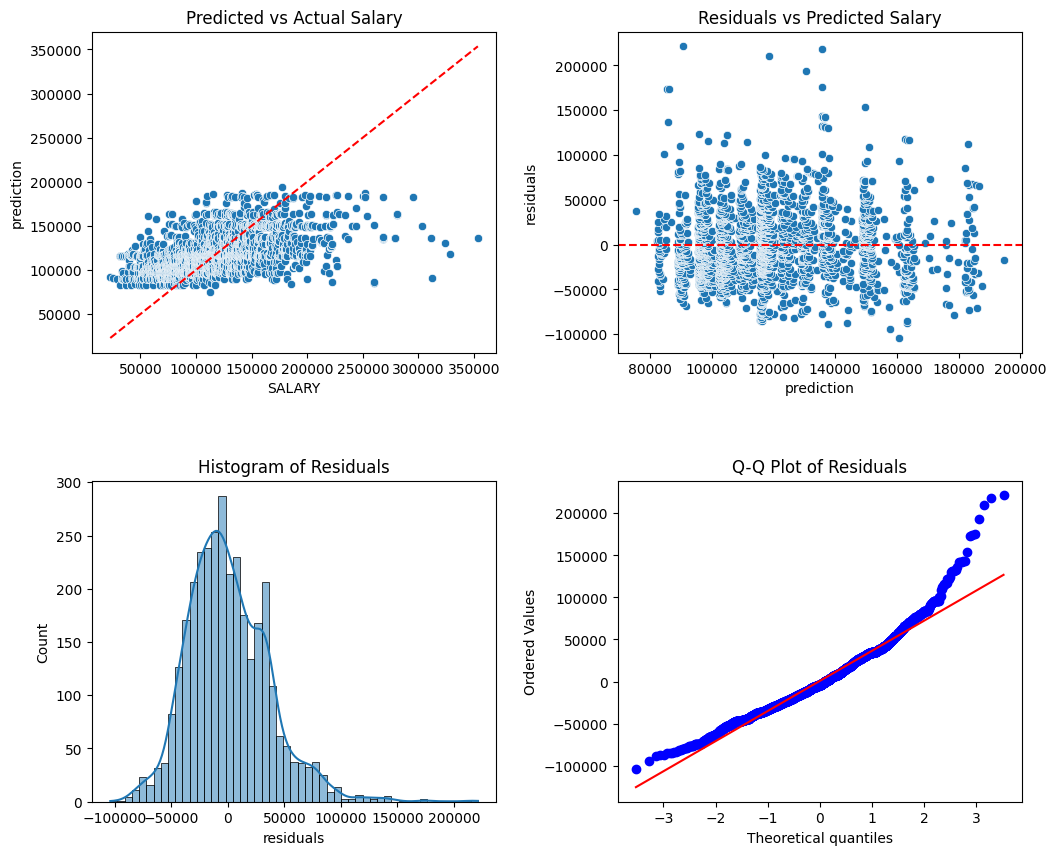

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

sns.scatterplot(x="SALARY", y="prediction", data=pred_df, ax=axes[0, 0])
axes[0, 0].plot([pred_df["SALARY"].min(), pred_df["SALARY"].max()],
                [pred_df["SALARY"].min(), pred_df["SALARY"].max()],
                color='red', linestyle='--')
axes[0, 0].set_title("Predicted vs Actual Salary")

sns.scatterplot(x="prediction", y="residuals", data=pred_df, ax=axes[0, 1])
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title("Residuals vs Predicted Salary")

sns.histplot(pred_df["residuals"].dropna(), kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Histogram of Residuals")

stats.probplot(pred_df["residuals"].dropna(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot of Residuals")

plt.savefig("_output/diagnostics_fixed.png", dpi=300)
plt.show()

In [14]:
print(pred_df[["SALARY", "prediction", "residuals"]].head())
print(pred_df["residuals"].describe())

   SALARY     prediction     residuals
0   22880   91612.441466 -68732.441466
1   24960   90641.130986 -65681.130986
2   29120   89791.234316 -60671.234316
3   31200   83146.007792 -51946.007792
4   31200  115582.950645 -84382.950645
count      3300.000000
mean        652.039094
std       36402.027703
min     -104184.440869
25%      -24362.893835
50%       -4175.137931
75%       23337.252411
max      221298.162109
Name: residuals, dtype: float64


In [16]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

y_true = pred_df["SALARY"].values
y_pred = pred_df["prediction"].values

r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

R²: 0.2643
RMSE: 36402.35
MAE: 28032.50


- R² = 0.2643：The model's explanatory power for wages is weak, explaining only about 26% of the variance, and there may be important missing variables.
- RMSE = 36402.35 : The average error between the predicted value and the actual value is $36,402, indicating some deviation from the predicted value.
- MAE = 28032.50 : The mean absolute error indicates an error of about $28,000 per forecast.

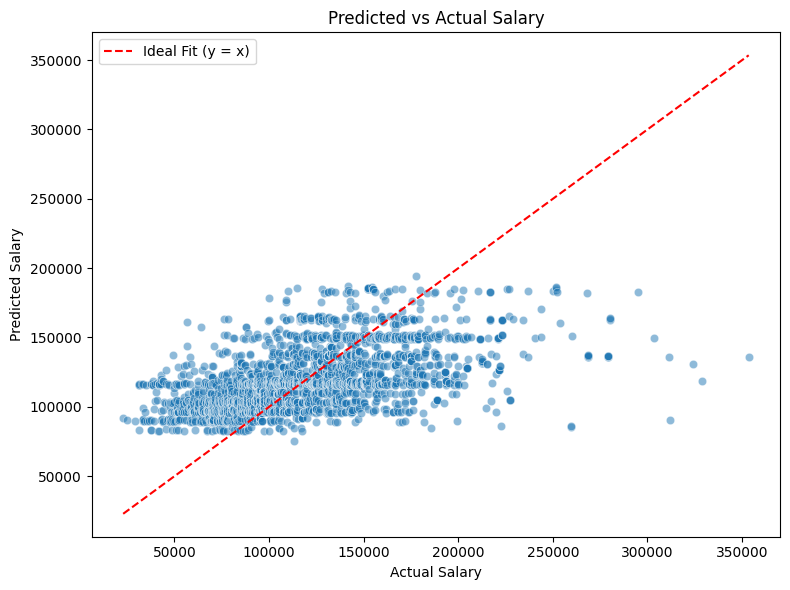

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("_output", exist_ok=True)

plt.figure(figsize=(8, 6))
sns.scatterplot(x="SALARY", y="prediction", data=pred_df, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
         color='red', linestyle='--', label='Ideal Fit (y = x)')
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Predicted vs Actual Salary")
plt.legend()
plt.tight_layout()
plt.savefig("_output/predicted_vs_actual_final.png", dpi=300)
plt.show()

The scatterplot compares actual salaries against predicted values. The red dashed line represents the ideal prediction (y=x). The majority of points lie below the line, indicating the model systematically overestimates salary, especially at lower salary levels.

In [19]:
plt.tight_layout()
fig.savefig("_output/model_diagnostic_plots.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [18]:
plt.savefig("_output/predicted_vs_actual_final.png", dpi=300)

<Figure size 640x480 with 0 Axes>